# 机器学习实验一：bank 数据任务代码框架

本 Notebook 供实验一使用，建议按顺序完成：

1. 读取 `bank_train.csv` 和 `bank_test.csv`
2. 做基础数据检查与预处理
3. 完成任务一：使用 `sklearn` 构建决策树
4. 完成任务二：手写 ID3
5. 完成选做题（可选）
6. 在实验报告中整理结果与分析

> 注意：请根据实验要求补全 `TODO` 部分。


## 0. 导入库


In [10]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

LABEL_COL = "approve"

## 1. 读取数据


In [29]:
train_path = Path("bank_train.csv")
test_path = Path("bank_test.csv")

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError("请确认当前文件夹中存在 bank_train.csv 和 bank_test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("训练集大小：", train_df.shape)
print("测试集大小：", test_df.shape)
train_df.head(5)


训练集大小： (800, 9)
测试集大小： (200, 9)


,nameid,profession,education,house_loan,car_loan,married,child,revenue,approve
0,1,5,1,0,0,1,1,8204,1
1,2,3,1,1,1,0,0,5674,0
2,3,2,3,1,0,1,0,10634,1
3,4,2,2,0,0,0,0,43551,1
4,5,4,2,0,1,0,1,14065,0


## 2. 数据检查与基础预处理

这一步建议完成：

- 查看字段名是否正确
- 检查是否有缺失值
- 查看标签 `approve` 的分布
- 删除编号列 `nameid`


In [30]:
print("训练集字段：", train_df.columns.tolist())
print("测试集字段：", test_df.columns.tolist())

print("\n训练集缺失值统计：")
print(train_df.isnull().sum())

print("\n测试集缺失值统计：")
print(test_df.isnull().sum())

print("\n训练集标签分布：")
print(train_df["approve"].value_counts())

# 删除不参与建模的编号列
train_base = train_df.drop(columns=["nameid"]).copy()
test_base = test_df.drop(columns=["nameid"]).copy()

# 遍历所有除了approve以外的列，组成列表
feature_cols = [c for c in train_base.columns if c != LABEL_COL]

print("\n特征列：", feature_cols)


训练集字段： ['nameid', 'profession', 'education', 'house_loan', 'car_loan', 'married', 'child', 'revenue', 'approve']
测试集字段： ['nameid', 'profession', 'education', 'house_loan', 'car_loan', 'married', 'child', 'revenue', 'approve']

训练集缺失值统计：
nameid        0
profession    0
education     0
house_loan    0
car_loan      0
married       0
child         0
revenue       0
approve       0
dtype: int64

测试集缺失值统计：
nameid        0
profession    0
education     0
house_loan    0
car_loan      0
married       0
child         0
revenue       0
approve       0
dtype: int64

训练集标签分布：
approve
1    518
0    282
Name: count, dtype: int64

特征列： ['profession', 'education', 'house_loan', 'car_loan', 'married', 'child', 'revenue']


# 3. 任务一：使用 sklearn 构建决策树

建议流程：

- 构造 `X / y`
- 从训练集中划分训练子集和验证集
- 至少比较 3 组参数
- 用验证集选择较优参数
- 用测试集做最终评估
- 绘制决策树


## 3.1 构造 `X / y`


In [45]:
# 构造训练集特征和标签
X_train_all = train_base[feature_cols]
y_train_all = train_base[LABEL_COL]

# 构造测试集特征和标签
X_test = test_base[feature_cols]
y_test = test_base[LABEL_COL]

print("训练集特征大小：", X_train_all.shape)
print("训练集标签大小：", y_train_all.shape)
print("测试集特征大小：", X_test.shape)
print("测试集标签大小：", y_test.shape)

训练集特征大小： (800, 7)
训练集标签大小： (800,)
测试集特征大小： (200, 7)
测试集标签大小： (200,)


## 3.2 划分训练集 / 验证集


In [35]:
# 采用5折交叉验证进行参数选择，不再额外划分固定验证集
# 交叉验证在训练集 X_train_all 和 y_train_all 内部完成

print("训练集大小：", X_train_all.shape)
print("测试集大小：", X_test.shape)
print("本实验采用5折交叉验证，K=5")

训练集大小： (800, 7)
测试集大小： (200, 7)
本实验采用5折交叉验证，K=5


## 3.3 参数设置与训练


In [37]:
# 导入交叉验证函数
from sklearn.model_selection import cross_validate

param_list = [
    {"criterion": "entropy", "max_depth": 3, "min_samples_split": 2, "min_samples_leaf": 1},
    {"criterion": "entropy", "max_depth": 5, "min_samples_split": 2, "min_samples_leaf": 1},
    {"criterion": "entropy", "max_depth": 7, "min_samples_split": 4, "min_samples_leaf": 2},
]

# 创建空列表保存结果
results = []

for params in param_list:
    clf = DecisionTreeClassifier(
        **params,
        random_state=42
    )

    scores = cross_validate(
        clf,
        X_train_all,
        y_train_all,
        cv=5,
        scoring=["accuracy", "precision", "recall", "f1"]
    )

    # 保存结果，mean求均值
    results.append({
        "params": params,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean()
    })

results_df = pd.DataFrame(results)
results_df

,params,accuracy,precision,recall,f1
0,"{'criterion': 'entropy', 'max_depth': 3, 'min_...",0.76875,0.771654,0.930396,0.839917
1,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.79875,0.776593,0.974832,0.863490
2,"{'criterion': 'entropy', 'max_depth': 7, 'min_...",0.75875,0.773127,0.891990,0.828076


## 3.4 选择参数并在测试集上评估


In [46]:
# 根据验证集F1-score选择最优参数
best_index = results_df["f1"].idxmax()
best_params = results_df.loc[best_index, "params"]

print("最优参数：", best_params)
print("验证集最优F1-score：", results_df.loc[best_index, "f1"])

# 用最优参数，在完整训练集上重新训练最终模型
final_clf = DecisionTreeClassifier(
    **best_params,
    random_state=42
)

final_clf.fit(X_train_all, y_train_all)

# 在测试集上预测
y_test_pred = final_clf.predict(X_test)

# 计算测试集评价指标
test_acc = accuracy_score(y_test, y_test_pred)
test_pre = precision_score(y_test, y_test_pred, zero_division=0)
test_rec = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

print("测试集 Accuracy：", test_acc)
print("测试集 Precision：", test_pre)
print("测试集 Recall：", test_rec)
print("测试集 F1-score：", test_f1)

最优参数： {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1}
验证集最优F1-score： 0.8634902436697537
测试集 Accuracy： 0.975
测试集 Precision： 1.0
测试集 Recall： 0.9698795180722891
测试集 F1-score： 0.9847094801223242


## 3.5 混淆矩阵与决策树可视化


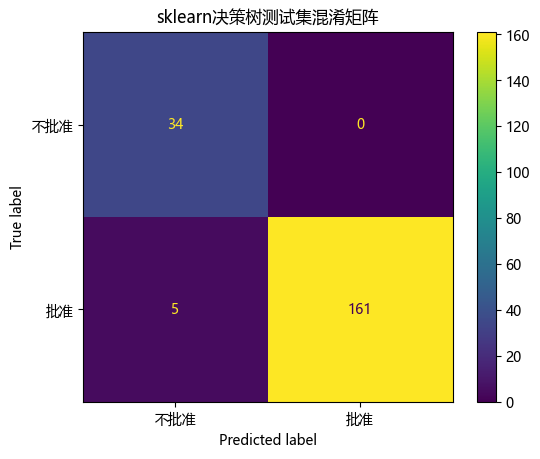

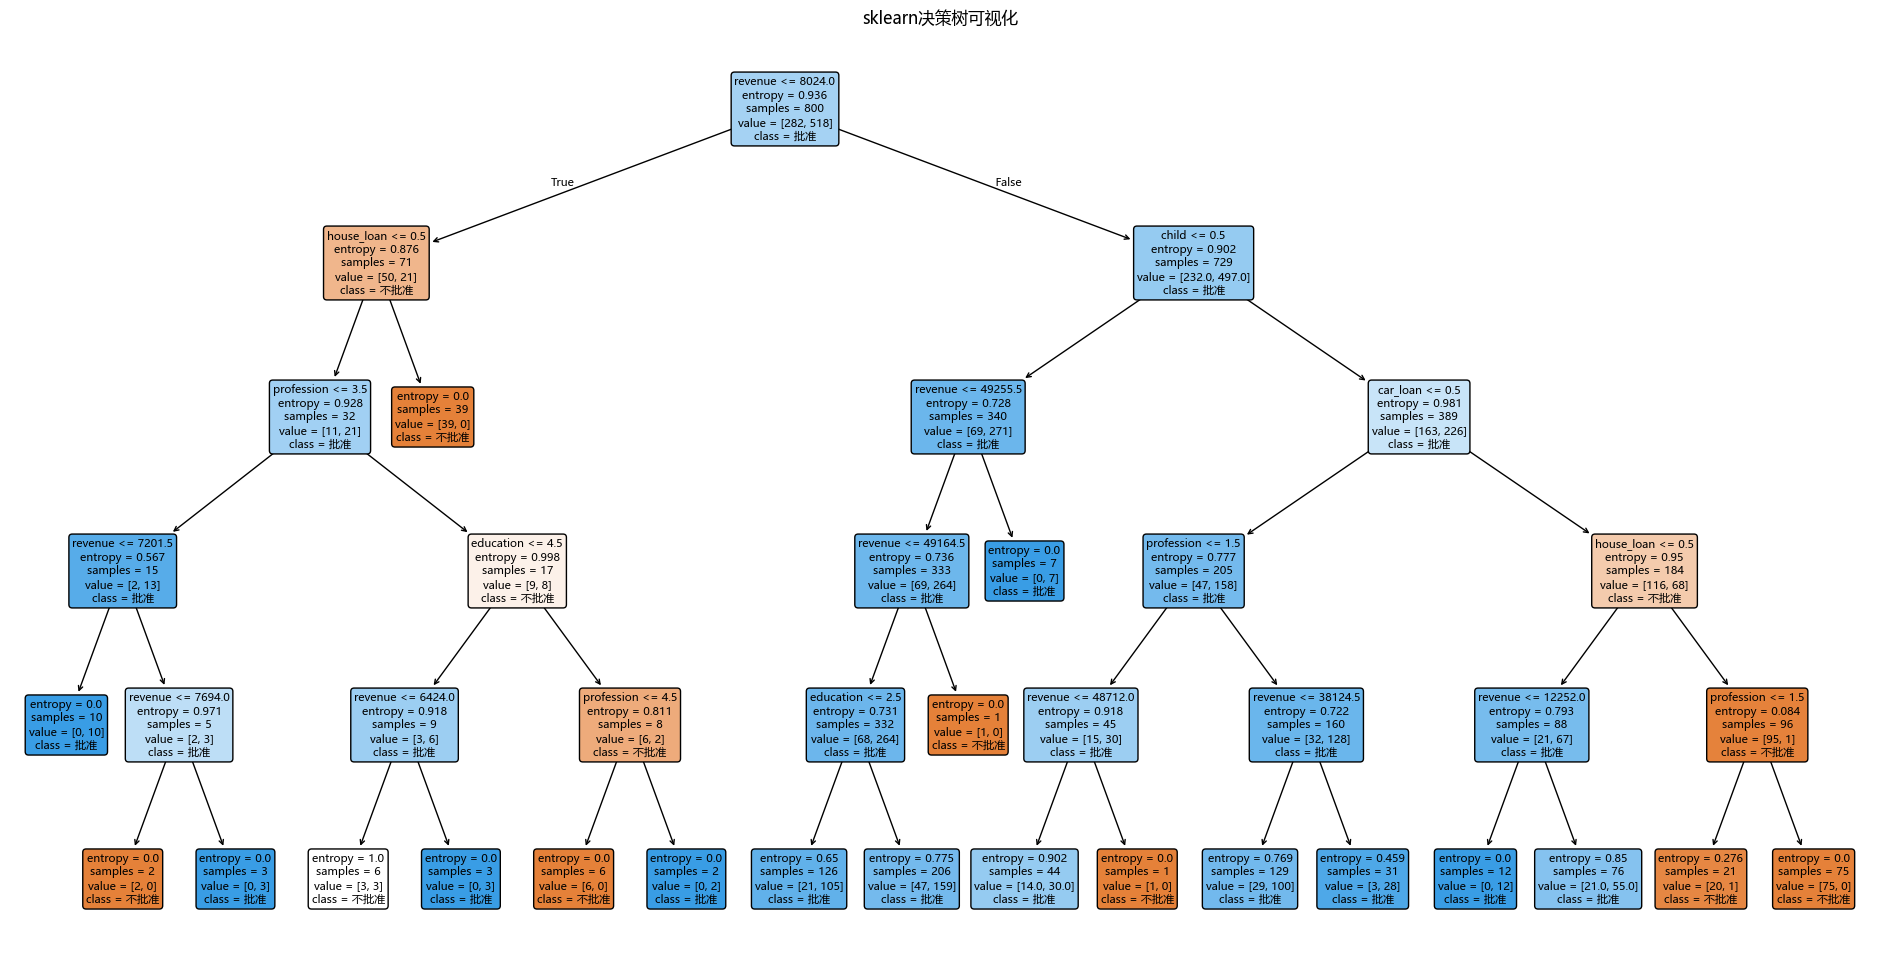

In [39]:
# 绘制混淆矩阵
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["不批准", "批准"]
)

disp.plot()
plt.title("sklearn决策树测试集混淆矩阵")
plt.show()

# 绘制决策树，并保存为png
plt.figure(figsize=(24, 12))

plot_tree(
    final_clf,
    feature_names=feature_cols,
    class_names=["不批准", "批准"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("sklearn决策树可视化")
plt.savefig("task1_tree.png", dpi=200, bbox_inches="tight")
plt.show()

# 4. 任务二：手写 ID3

任务二统一采用：

- 离散特征、多叉树版 ID3
- `revenue` 需要先离散化
- 预测时要处理未见过属性值（fallback）


## 4.1 `revenue` 离散化


In [40]:
# 给任务二单独准备一份数据，避免和任务一互相影响
train_id3 = train_base.copy()
test_id3 = test_base.copy()

# 对revenue进行离散化
# ID3更适合处理离散特征，所以把连续收入分成几个收入区间
bins = [-np.inf, 10000, 20000, 30000, 40000, np.inf]
labels = ["低收入", "中低收入", "中收入", "中高收入", "高收入"]

train_id3["revenue"] = pd.cut(
    train_id3["revenue"],
    bins=bins,
    labels=labels
)

test_id3["revenue"] = pd.cut(
    test_id3["revenue"],
    bins=bins,
    labels=labels
)

print("训练集revenue离散化后分布：")
print(train_id3["revenue"].value_counts())

print("\n测试集revenue离散化后分布：")
print(test_id3["revenue"].value_counts())

train_id3.head()

训练集revenue离散化后分布：
revenue
中低收入    290
中收入     158
低收入     133
高收入     115
中高收入    104
Name: count, dtype: int64

测试集revenue离散化后分布：
revenue
中低收入    69
高收入     36
低收入     34
中高收入    32
中收入     29
Name: count, dtype: int64


,profession,education,house_loan,car_loan,married,child,revenue,approve
0,5,1,0,0,1,1,低收入,1
1,3,1,1,1,0,0,低收入,0
2,2,3,1,0,1,0,中低收入,1
3,2,2,0,0,0,0,高收入,1
4,4,2,0,1,0,1,中低收入,0


## 4.2 核心函数骨架


In [44]:
# 计算信息熵
def calc_entropy(data, label=LABEL_COL):
    """
    计算数据集的熵。
    熵越大，说明数据越混乱；熵越小，说明数据越纯。
    """
    if len(data) == 0:
        return 0

    label_counts = data[label].value_counts()
    total = len(data)

    entropy = 0.0
    for count in label_counts:
        p = count / total
        entropy -= p * np.log2(p)

    return entropy

# 计算条件熵
def calc_info_gain(data, feature, label=LABEL_COL):
    """
    计算某个特征的信息增益。
    信息增益=划分前的熵-划分后的条件熵。
    """
    total_entropy = calc_entropy(data, label)
    total = len(data)

    conditional_entropy = 0.0

    # observed=True表示只遍历真实出现过的类别，避免空分组
    for value, subset in data.groupby(feature, observed=True):
        if len(subset) == 0:
            continue
        weight = len(subset) / total
        conditional_entropy += weight * calc_entropy(subset, label)

    info_gain = total_entropy - conditional_entropy
    return info_gain

# 找当前数据里数量最多的类别，兜底
def majority_class(data, label=LABEL_COL, default_class=0):
    """
    返回当前数据集中数量最多的类别。
    如果数据为空，就返回默认类别。
    """
    if len(data) == 0:
        return default_class

    counts = data[label].value_counts()

    if len(counts) == 0:
        return default_class

    return counts.idxmax()

# 递归构建决策树
def build_tree(data, features, label=LABEL_COL, max_depth=None, current_depth=0, parent_majority=None):
    
    # 如果当前数据为空，返回父节点多数类作为兜底
    if len(data) == 0:
        return parent_majority

    # 当前节点的多数类，后面fallback会用到
    majority = majority_class(data, label, default_class=parent_majority)

    # 情况1：当前数据全是同一类，直接返回这个类别
    if data[label].nunique() == 1:
        return data[label].iloc[0]

    # 情况2：没有特征可以继续划分，返回多数类
    if len(features) == 0:
        return majority

    # 情况3：达到最大深度，返回多数类
    if max_depth is not None and current_depth >= max_depth:
        return majority

    # 计算每个特征的信息增益
    gains = {}
    for feature in features:
        gains[feature] = calc_info_gain(data, feature, label)

    # 选择信息增益最大的特征
    best_feature = max(gains, key=gains.get)
    best_gain = gains[best_feature]

    # 如果信息增益几乎为0，说明再分也没什么意义
    if best_gain <= 1e-12:
        return majority

    # 创建当前内部节点
    tree = {
        "feature": best_feature,
        "majority": majority,
        "children": {}
    }

    # 剩余特征
    remaining_features = [f for f in features if f != best_feature]

    # observed=True表示只对真实出现过的取值建分支，避免空分支
    for value, subset in data.groupby(best_feature, observed=True):
        if len(subset) == 0:
            continue

        tree["children"][value] = build_tree(
            subset,
            remaining_features,
            label=label,
            max_depth=max_depth,
            current_depth=current_depth + 1,
            parent_majority=majority
        )

    return tree


def predict_one(tree, sample):
    """
    对单个样本进行预测。
    如果遇到训练时没出现过的特征取值，就返回当前节点的majority。
    """
    # 如果已经是叶子节点，直接返回类别
    if not isinstance(tree, dict):
        return tree

    feature = tree["feature"]
    value = sample[feature]

    # fallback：测试样本的取值没在当前节点出现过
    if value not in tree["children"]:
        return tree["majority"]

    return predict_one(tree["children"][value], sample)


def predict(tree, data):
    """
    对整个数据集进行批量预测。
    """
    preds = []
    for _, row in data.iterrows():
        preds.append(predict_one(tree, row))
    return np.array(preds)

## 4.3 模型训练与测试集评估


In [42]:
# 准备任务二的训练特征列表
id3_features = [c for c in train_id3.columns if c != LABEL_COL]

print("ID3使用的特征：", id3_features)

# 构建手写ID3决策树
tree = build_tree(
    train_id3,
    id3_features,
    label=LABEL_COL,
    max_depth=None
)

# 在测试集上预测
X_test_id3 = test_id3[id3_features]
y_true = test_id3[LABEL_COL].values
y_pred_id3 = predict(tree, X_test_id3)

# 手写计算TP、TN、FP、FN
TP = np.sum((y_true == 1) & (y_pred_id3 == 1))
TN = np.sum((y_true == 0) & (y_pred_id3 == 0))
FP = np.sum((y_true == 0) & (y_pred_id3 == 1))
FN = np.sum((y_true == 1) & (y_pred_id3 == 0))

print("TP真正例：", TP)
print("TN真负例：", TN)
print("FP假正例：", FP)
print("FN假负例：", FN)

# 手写计算指标
accuracy_id3 = (TP + TN) / (TP + TN + FP + FN)

precision_id3 = TP / (TP + FP) if (TP + FP) != 0 else 0
recall_id3 = TP / (TP + FN) if (TP + FN) != 0 else 0
f1_id3 = (
    2 * precision_id3 * recall_id3 / (precision_id3 + recall_id3)
    if (precision_id3 + recall_id3) != 0
    else 0
)

print("\n手写ID3测试集Accuracy：", accuracy_id3)
print("手写ID3测试集Precision：", precision_id3)
print("手写ID3测试集Recall：", recall_id3)
print("手写ID3测试集F1-score：", f1_id3)

ID3使用的特征： ['profession', 'education', 'house_loan', 'car_loan', 'married', 'child', 'revenue']
TP真正例： 128
TN真负例： 33
FP假正例： 1
FN假负例： 38

手写ID3测试集Accuracy： 0.805
手写ID3测试集Precision： 0.9922480620155039
手写ID3测试集Recall： 0.7710843373493976
手写ID3测试集F1-score： 0.8677966101694916


## 对比表

In [43]:
compare_df = pd.DataFrame([
    {
        "模型": "sklearn决策树",
        "Accuracy": test_acc,
        "Precision": test_pre,
        "Recall": test_rec,
        "F1-score": test_f1
    },
    {
        "模型": "手写ID3决策树",
        "Accuracy": accuracy_id3,
        "Precision": precision_id3,
        "Recall": recall_id3,
        "F1-score": f1_id3
    }
])

compare_df

,模型,Accuracy,Precision,Recall,F1-score
0,sklearn决策树,0.975,1.000000,0.969880,0.984709
1,手写ID3决策树,0.805,0.992248,0.771084,0.867797


## 4.4 选做题：预剪枝（可选）

选做题思路：

- 在 4.2 的 `build_tree` 函数中，已经预留了 `max_depth` 和 `current_depth`
- 基础任务中可以保持 `max_depth=None`，表示不限制树的最大深度
- 当 `max_depth is not None` 且 `current_depth >= max_depth` 时停止递归，返回当前多数类
- 递归构建子树时，将 `current_depth + 1` 传入下一层
- 比较 `max_depth = 3, 5, 10, None` 的结果


In [28]:
# TODO：选做题实验位置
# 你可以在这里调用带 max_depth 的 build_tree
# 并比较不同深度下的 Precision / Recall / F1
